# Lecture 6: Exercise 2 — Solution

## Objective

Replicate two model combinations from the paper of Schetgen et al. (2021):
1. **SVD + Random Forest**
2. **LDA + Random Forest**

Both with $k = 25$ dimensions/LDA. We compare their performance to the SVD + Logistic Regression model from the examples notebook.

## Tasks

1. **Perform LDA** on the training data to extract LDA features.
2. **Train two models:**
   - SVD + Random Forest
   - LDA + Random Forest 
3. **Evaluate** both models using AUC and Top Decile Lift (TDL).
4. **Assess variable importance** for both models.
5. **Analyze the underlying structures:**
   - For SVD, examine the most important concepts.
   - For LDA, identify the most important words for key topics.
6. **Compare** results with the original SVD + Logistic Regression model and the paper's findings.
7. **Discuss** any differences in performance and why they occur.

> **Hint for LDA:** LDA can only be applied to users who liked at least one page/group/category. Use the helper function below to track which rows are kept:
> ```python
> def get_kept_indices(df, top_cols):
>     subset = df[top_cols]
>     return subset.sum(axis=1) > 0
> ```
> Apply this to both train and test sets before fitting LDA.

## Solution

This solution implements two topic-modelling pipelines for donor prediction, comparing:
- **SVD + Random Forest**: `TruncatedSVD` compresses each feature block (pages, categories, groups) into $k = 25$ latent dimensions
- **LDA + Random Forest**: `LatentDirichletAllocation` models each user as a mixture over $k=25$ latent topics; because LDA requires at least one active item per user, inactive rows are filtered before fitting and re-aligned by index when building the basetable.
- **SVD + LASSO LR (baseline)**: Identical `Pipeline` architecture to SVD + RF but with L1-penalised Logistic Regression — directly comparable to the example notebook. 

**Key implementation details:**
- **`k = 25` throughout**
- **Pipeline pattern**: All feature engineering is encapsulated in `sklearn` `Pipeline` + `ColumnTransformer` objects; `fit` only ever sees training data
- **Top-500 feature selection**: Only the 500 most frequent pages, groups, and categories are retained to manage memory and reduce noise
- **Evaluation metrics**: AUC and Top Decile Lift (TDL)

### Step 1: Import Libraries and Configure Environment

Import all required packages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

np.random.seed(68)

print("✓ All packages loaded successfully!")

✓ All packages loaded successfully!


### Step 2: Load the Donation Dataset

Load all four data tables (users, pages, categories, groups) for both the train and test splits.

**Dataset structure:**
- `users_TRAIN/TEST`: User-level demographic and behavioural features, plus the `donor` target variable
- `pages_TRAIN/TEST`: Binary/count matrix of Facebook pages liked by each user
- `categories_TRAIN/TEST`: Binary/count matrix of page categories liked by each user
- `groups_TRAIN/TEST`: Binary/count matrix of Facebook groups joined by each user

In [2]:
# Load all feature matrices for train and test splits
users_train = pd.read_csv('Data/Donation/usersTRAIN.csv')
users_test = pd.read_csv('Data/Donation/usersTEST.csv')
pages_train = pd.read_csv('Data/Donation/pagesTRAIN.csv')
pages_test = pd.read_csv('Data/Donation/pagesTEST.csv')
categories_train = pd.read_csv('Data/Donation/categoriesTRAIN.csv')
categories_test = pd.read_csv('Data/Donation/categoriesTEST.csv')
groups_train = pd.read_csv('Data/Donation/groupsTRAIN.csv')
groups_test = pd.read_csv('Data/Donation/groupsTEST.csv')

# Extract target variable
y_train = users_train['donor']
y_test = users_test['donor']

print(f"✓ Data loaded successfully!")
print(f"  Users train: {users_train.shape}, test: {users_test.shape}")
print(f"  Pages train: {pages_train.shape}, test: {pages_test.shape}")
print(f"  Categories train: {categories_train.shape}, test: {categories_test.shape}")
print(f"  Groups train: {groups_train.shape}, test: {groups_test.shape}")

print(f"\nTarget distribution (train):")
print(f"  Donors:     {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")
print(f"  Non-donors: {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")

print(f"\nTarget distribution (test):")
print(f"  Donors:     {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")
print(f"  Non-donors: {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")

✓ Data loaded successfully!
  Users train: (4936, 4), test: (1889, 4)
  Pages train: (4936, 3996), test: (1889, 3996)
  Categories train: (4936, 1001), test: (1889, 1001)
  Groups train: (4936, 1286), test: (1889, 1286)

Target distribution (train):
  Donors:     1170 (23.7%)
  Non-donors: 3766 (76.3%)

Target distribution (test):
  Donors:     108 (5.7%)
  Non-donors: 1781 (94.3%)


### Step 3: Select Top Features (Top-500 per Block)

The raw feature matrices have thousands of columns for every unique Facebook page, category, or group in the dataset. We retain only the **500 most frequent** items per block.

**Why top-500?**
- **Memory**: The raw matrices are extremely wide; keeping all columns would exhaust RAM when constructing the full feature matrix
- **Signal-to-noise**: Rare pages/groups appear in very few users and carry little statistical signal. They are essentially noise for the downstream classifier. 
- **Computation**: Both `TruncatedSVD` and `LatentDirichletAllocation` scale with the number of columns; reducing it from thousands to 500 speeds up fitting significantly

In [3]:
def select_top_n(df, n=500):
    """Select the top-n most frequent columns (by sum)."""
    return df.sum().nlargest(n).index.tolist()

top_pages = select_top_n(pages_train)
top_groups = select_top_n(groups_train)
top_categories = select_top_n(categories_train)

print(f"Top pages: {len(top_pages)}, groups: {len(top_groups)}, categories: {len(top_categories)}")

Top pages: 500, groups: 500, categories: 500



## Part 1: SVD + Random Forest

### Step 4: Build the Feature Matrix

Construct a wide DataFrame that merges user-level features with the three behaviour matrices (pages, categories, groups). Each block is given **prefixed column names** (`pages__`, `cat__`, `grp__`) to avoid naming conflicts.

A `ColumnTransformer` will later apply `TruncatedSVD` independently to each prefixed block and pass user features through unchanged. Prefixing means the transformer can select each block unambiguously by column name pattern.

**Why build the wide DataFrame first?**
Sklearn's `Pipeline` + `ColumnTransformer` pattern requires all inputs to come from a single DataFrame. By pre-joining the feature blocks here, we can hand one flat `X_train_full` / `X_test_full` to `pipeline.fit()` and `pipeline.predict_proba()` — the pipeline handles all the internal splitting, SVD fitting, and projection automatically.

In [4]:
k = 25

# User-level features (passed through unchanged)
user_cols = list(users_train.drop(columns=['donor', 'id'], errors='ignore').columns)

# Prefix each block to avoid column name collisions across the three matrices
pages_cols = ['pages__' + c for c in top_pages]
cat_cols   = ['cat__'   + c for c in top_categories]
grp_cols   = ['grp__'   + c for c in top_groups]

pages_train_p = pages_train[top_pages].rename(columns=lambda c: 'pages__' + c)
pages_test_p  = pages_test[top_pages].rename(columns=lambda c: 'pages__' + c)
cat_train_p   = categories_train[top_categories].rename(columns=lambda c: 'cat__' + c)
cat_test_p    = categories_test[top_categories].rename(columns=lambda c: 'cat__' + c)
grp_train_p   = groups_train[top_groups].rename(columns=lambda c: 'grp__' + c)
grp_test_p    = groups_test[top_groups].rename(columns=lambda c: 'grp__' + c)

X_train_full = pd.concat([
    users_train[user_cols].reset_index(drop=True),
    pages_train_p.reset_index(drop=True),
    cat_train_p.reset_index(drop=True),
    grp_train_p.reset_index(drop=True)
], axis=1)

X_test_full = pd.concat([
    users_test[user_cols].reset_index(drop=True),
    pages_test_p.reset_index(drop=True),
    cat_test_p.reset_index(drop=True),
    grp_test_p.reset_index(drop=True)
], axis=1)

print(f"Feature matrix — train: {X_train_full.shape}, test: {X_test_full.shape}")

Feature matrix — train: (4936, 1502), test: (1889, 1502)


### Step 5: Fit the SVD + Random Forest Pipeline

The `ColumnTransformer` applies `TruncatedSVD(n_components=25)` independently to each of the three feature blocks, then concatenates the reduced representations with the passthrough user features into a single dense matrix. The `Pipeline` chains this preprocessor with a `RandomForestClassifier`.

**Why `TruncatedSVD` instead of full SVD?**
- **Memory-efficient**: Computes only the top $k$ singular vectors, no need to decompose the full $p \times p$ matrix
- **Sparse-friendly**: Works directly on (effectively) sparse matrices, which the wide page/category/group matrices are
- **Pipeline-compatible**: Fits inside a `Pipeline`, so training vs test projections are handled automatically

In [ ]:
# ColumnTransformer: TruncatedSVD on each feature block, user features passed through unchanged
preprocessor = ColumnTransformer([
    ('user',      'passthrough',                                   user_cols),
    ('pages_svd', TruncatedSVD(n_components=k, random_state=42),  pages_cols),
    ('cat_svd',   TruncatedSVD(n_components=k, random_state=42),  cat_cols),
    ('grp_svd',   TruncatedSVD(n_components=k, random_state=42),  grp_cols),
], remainder='drop')

# Build feature names for variable importance plots
feature_names_svd = (
    user_cols
    + [f'pages_dim{i+1}' for i in range(k)]
    + [f'cat_dim{i+1}' for i in range(k)]
    + [f'grp_dim{i+1}' for i in range(k)]
)

# Pipeline: SVD preprocessing → Random Forest
pipeline_rf_svd = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(n_estimators=500, random_state=42))
])

pipeline_rf_svd.fit(X_train_full, y_train)
pred_rf_svd = pipeline_rf_svd.predict_proba(X_test_full)[:, 1]

print("✓ SVD + Random Forest pipeline fitted successfully!")
print(f"  Features after SVD: {len(feature_names_svd)}")

✓ SVD + Random Forest pipeline fitted successfully!
  Features after SVD: 77


### Step 6: Evaluate — AUC and Top Decile Lift

We use two complementary metrics throughout this exercise:

- **AUC (Area Under the ROC Curve)**
- **Top Decile Lift (TDL)**.

**Why TDL matters?** 

In direct-marketing campaigns you typically only contact a small fraction of prospects (e.g., the top decile). TDL directly measures how much more cost-efficient the model makes the campaign: a higher TDL means the same mailing budget reaches proportionally more genuine donors. So it is directly linkable to the profits generated by the campaign and can be easily understood by managers. 

In [6]:
def top_decile_lift(y_true, y_pred):
    """Compute lift in the top 10% of predicted probabilities."""
    n = len(y_true)
    top_n = max(1, n // 10)
    order = np.argsort(y_pred)[::-1]
    top_actual = np.array(y_true)[order][:top_n]
    return top_actual.mean() / max(np.array(y_true).mean(), 1e-10)

auc_svd = roc_auc_score(y_test, pred_rf_svd)
tdl_svd = top_decile_lift(y_test, pred_rf_svd)

print(f"SVD + Random Forest")
print(f"  AUC:              {auc_svd:.4f}")
print(f"  Top Decile Lift:  {tdl_svd:.3f}")

SVD + Random Forest
  AUC:              0.8855
  Top Decile Lift:  6.233


### Step 7: Variable Importance — SVD + RF

Random Forests report **mean decrease in Gini impurity** per feature. A higher value means the feature creates more informative splits across more trees.

**Interpretation note:** The importances here refer to *SVD dimensions*, not the original pages/groups/categories. A high-importance SVD dimension captures a latent behavioural pattern that is predictive of donation. To understand *which* original items that pattern corresponds to, you need to inspect the `components_` matrix (see Step 8).

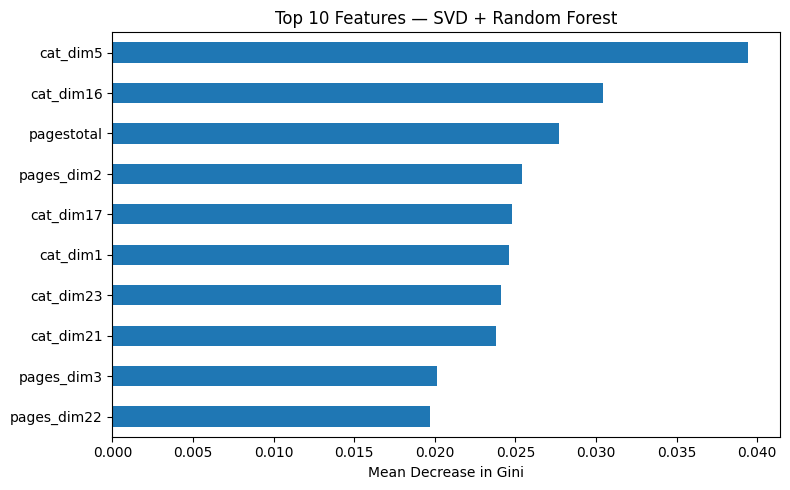

In [7]:
gini_svd = (
    pd.Series(
        pipeline_rf_svd.named_steps['rf'].feature_importances_,
        index=feature_names_svd
    )
    .nlargest(10)
    .sort_values()
)

plt.figure(figsize=(8, 5))
gini_svd.plot.barh()
plt.xlabel('Mean Decrease in Gini')
plt.title('Top 10 Features — SVD + Random Forest')
plt.tight_layout()
plt.show()

### Step 8: Interpret SVD Dimensions

The SVD `components_` matrix has shape $(k,\, p)$: each row is a latent dimension and each column is an original feature (page/category/group). Items with large absolute loadings on a dimension are the ones that dimension "represents".

**Accessing components from the pipeline:**
```python
pipeline_rf_svd.named_steps['preprocessor'].named_transformers_['cat_svd'].components_
```
This is equivalent to the $V^T$ matrix from the lecture slide, but obtained directly from the fitted sklearn object.

**How to read the output:** A positive loading means the item co-occurs with other items that define this dimension; a negative loading means the opposite. When interpreting, focus on the items with the highest *absolute* scores, regardless of sign.

In [8]:
# Extract the fitted TruncatedSVD for categories from the pipeline
svd_cat_fitted = pipeline_rf_svd.named_steps['preprocessor'].named_transformers_['cat_svd']

# components_ shape: (k, n_categories) — each row is an SVD dimension
interp_categories = pd.DataFrame(
    svd_cat_fitted.components_.T,           # transpose → (n_categories, k)
    columns=[f'dim{i+1}' for i in range(k)],
    index=top_categories
)
interp_categories.index.name = 'category'

# Example: top categories loading on dimension 5
(interp_categories[['dim5']]
 .assign(abs_score=lambda x: x['dim5'].abs())
 .nlargest(10, 'abs_score')
 .drop(columns='abs_score'))

,dim5
category,
Theater voor uitvoerende kunsten,0.204097
Festival,0.190124
Voor de lol,-0.180743
Caf\u00e9,0.174257
Bar,0.173466
Evenement,0.155208
Jeugdorganisatie,0.154441
Media,-0.153050
Restaurant,0.147916



## Part 2: LDA + Random Forest

### Step 9: Apply LDA ($k = 25$)

**What LDA does:** 

Latent Dirichlet Allocation models each user as a probability distribution over $k$ latent topics, and each topic as a probability distribution over items (pages/categories/groups). After fitting, the topic proportions for each user become the feature representation fed to the classifier: similar in spirit to SVD dimensions but with a probabilistic, fully non-negative interpretation. Hence, you can see LDA as a feature extraction technique just like SVD or PCA and not just as a pure topic modeling method. 

**Why filtering users with no activity?** 

From a theoretical standpoint, the LDA generative model assumes every document contains at least one word: a user who liked nothing has no evidence to inform their topic distribution. Keeping such rows would assign them a uniform topic distribution (the Dirichlet prior), which is uninformative and adds noise to the downstream classifier.

In practice, sklearn's `LatentDirichletAllocation` handles all-zero rows without error (it simply falls back to the prior). However, libraries such as `gensim` can fail on empty documents. We apply the filter here to remain consistent with the theoretical model and to keep the code portable across implementations. There is no downside to doing so: users with zero activity carry no useful signal anyway, so excluding them does not lose any information.

In [9]:
def get_kept_indices(df, top_cols):
    """Return indices of rows that have at least one non-zero value in top_cols."""
    subset = df[top_cols]
    mask = subset.sum(axis=1) > 0
    return mask

# Determine which users to keep for each matrix
mask_pages_train = get_kept_indices(pages_train, top_pages)
mask_pages_test = get_kept_indices(pages_test, top_pages)
mask_cat_train = get_kept_indices(categories_train, top_categories)
mask_cat_test = get_kept_indices(categories_test, top_categories)
mask_grp_train = get_kept_indices(groups_train, top_groups)
mask_grp_test = get_kept_indices(groups_test, top_groups)

print(f"Pages — kept train: {mask_pages_train.sum()}/{len(mask_pages_train)}, "
      f"test: {mask_pages_test.sum()}/{len(mask_pages_test)}")
print(f"Categories — kept train: {mask_cat_train.sum()}/{len(mask_cat_train)}, "
      f"test: {mask_cat_test.sum()}/{len(mask_cat_test)}")
print(f"Groups — kept train: {mask_grp_train.sum()}/{len(mask_grp_train)}, "
      f"test: {mask_grp_test.sum()}/{len(mask_grp_test)}")

Pages — kept train: 4933/4936, test: 1888/1889
Categories — kept train: 4936/4936, test: 1889/1889
Groups — kept train: 3325/4936, test: 1251/1889


In [10]:
# --- LDA on Pages ---
lda_pages = LatentDirichletAllocation(n_components=k, random_state=1234)
lda_pages_train = lda_pages.fit_transform(pages_train.loc[mask_pages_train, top_pages])
lda_pages_test = lda_pages.transform(pages_test.loc[mask_pages_test, top_pages])

# --- LDA on Categories ---
lda_cat = LatentDirichletAllocation(n_components=k, random_state=1234)
lda_cat_train = lda_cat.fit_transform(categories_train.loc[mask_cat_train, top_categories])
lda_cat_test = lda_cat.transform(categories_test.loc[mask_cat_test, top_categories])

# --- LDA on Groups ---
lda_grp = LatentDirichletAllocation(n_components=k, random_state=1234)
lda_grp_train = lda_grp.fit_transform(groups_train.loc[mask_grp_train, top_groups])
lda_grp_test = lda_grp.transform(groups_test.loc[mask_grp_test, top_groups])

print(f"LDA pages train: {lda_pages_train.shape}, test: {lda_pages_test.shape}")
print(f"LDA categories train: {lda_cat_train.shape}, test: {lda_cat_test.shape}")
print(f"LDA groups train: {lda_grp_train.shape}, test: {lda_grp_test.shape}")

LDA pages train: (4933, 25), test: (1888, 25)
LDA categories train: (4936, 25), test: (1889, 25)
LDA groups train: (3325, 25), test: (1251, 25)


### Step 10: Build the LDA Basetable

Because LDA drops users who liked none of the top items, the resulting topic-proportion matrices have fewer rows than the original user table. We must **re-align by row index** before joining user-level features and the target variable.

**The alignment challenge:** 

Filtering is applied independently for pages, categories, and groups, so a user dropped from the pages LDA matrix may still be present in the categories or groups matrices. We use an `inner join` on the original DataFrame index to keep only users that survived all three filters. 

Filling with zeros (the Dirichlet prior) would add spurious rows where all topic proportions are identical — the default prior distribution. Those rows would mislead the classifier without adding any real information. Hence, an inner join guarantees a consistent, rectangular basetable with no missing values from missaligned rows.

In [11]:
def build_lda_basetable(users, lda_pages, lda_cat, lda_grp,
                        mask_pages, mask_cat, mask_grp, k):
    """Build combined basetable from LDA dimensions + user features, aligned by row index."""
    page_cols = [f'pages_dim{i+1}' for i in range(k)]
    cat_cols = [f'categories_dim{i+1}' for i in range(k)]
    grp_cols = [f'groups_dim{i+1}' for i in range(k)]

    # Create DataFrames with original row indices
    df_pages = pd.DataFrame(lda_pages, columns=page_cols,
                            index=users.index[mask_pages])
    df_cat = pd.DataFrame(lda_cat, columns=cat_cols,
                          index=users.index[mask_cat])
    df_grp = pd.DataFrame(lda_grp, columns=grp_cols,
                          index=users.index[mask_grp])

    # Inner join on index to keep only users present in all three
    df = df_pages.join(df_cat, how='inner').join(df_grp, how='inner')

    # Add user-level features
    user_feats = users.drop(columns=['donor', 'id'], errors='ignore')
    df = df.join(user_feats, how='inner')

    return df

X_train_lda = build_lda_basetable(
    users_train, lda_pages_train, lda_cat_train, lda_grp_train,
    mask_pages_train, mask_cat_train, mask_grp_train, k
)
X_test_lda = build_lda_basetable(
    users_test, lda_pages_test, 
    lda_cat_test, lda_grp_test,
    mask_pages_test, mask_cat_test, mask_grp_test, k
)

# Align target variable with the kept rows
y_train_lda = y_train.loc[X_train_lda.index]
y_test_lda = y_test.loc[X_test_lda.index]

print(f"LDA basetable — train: {X_train_lda.shape}, test: {X_test_lda.shape}")
print(f"Target (train): {y_train_lda.value_counts().to_string()}")
print(f"Target (test): {y_test_lda.value_counts().to_string()}")

LDA basetable — train: (3325, 77), test: (1251, 77)
Target (train): donor
0    2565
1     760
Target (test): donor
0    1184
1      67


### Step 11: Train the LDA + Random Forest

Train a Random Forest directly on the LDA topic proportions (plus user-level features). Note that here we **do not** use a `Pipeline` as we did for SVD — the LDA preprocessing was handled manually above because the index-alignment step for inactive users falls outside what a standard `ColumnTransformer` can express cleanly.

**Implication:** The `y_train_lda` and `y_test_lda` targets are aligned subsets of the original `y_train` / `y_test`, restricted to users that survived all three LDA filters. Evaluation in Step 12 is therefore on a slightly reduced test set.

In [12]:
# Train Random Forest directly on LDA topic proportions + user features
rf_lda = RandomForestClassifier(n_estimators=500, random_state=42)
rf_lda.fit(X_train_lda, y_train_lda)

pred_rf_lda = rf_lda.predict_proba(X_test_lda)[:, 1]
print("✓ LDA + Random Forest fitted successfully!")

✓ LDA + Random Forest fitted successfully!


### Step 12: Evaluate — AUC and Top Decile Lift

In [13]:
auc_lda = roc_auc_score(y_test_lda, pred_rf_lda)
tdl_lda = top_decile_lift(y_test_lda, pred_rf_lda)

print(f"LDA + Random Forest")
print(f"  AUC:              {auc_lda:.4f}")
print(f"  Top Decile Lift:  {tdl_lda:.3f}")

LDA + Random Forest
  AUC:              0.8533
  Top Decile Lift:  6.124


### Step 13: Variable Importance — LDA + RF

As with SVD, variable importance here refers to **LDA topic dimensions**, not raw items. The interpretation is analogous: a high-importance topic is a latent behavioural pattern (mix of pages/groups/categories) that the Random Forest finds predictive of donation.

To understand the *content* of an important topic, inspect its top items in the `components_` matrix (Step 14).

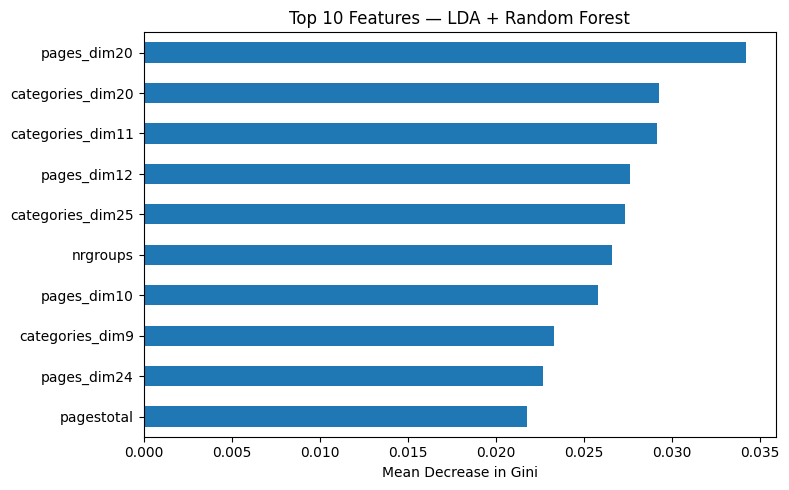

In [14]:
gini_lda = (
    pd.Series(rf_lda.feature_importances_, index=X_train_lda.columns)
    .nlargest(10)
    .sort_values()
)

plt.figure(figsize=(8, 5))
gini_lda.plot.barh()
plt.xlabel('Mean Decrease in Gini')
plt.title('Top 10 Features — LDA + Random Forest')
plt.tight_layout()
plt.show()

### Step 14: Interpret LDA Topics

In LDA, the `components_` matrix has shape $(k,\, p)$, identical structure to SVD's `components_`, but the values represent **unnormalised topic–item weights** rather than singular vectors. Normalising each row to sum to 1 gives the probability that the topic "generates" each item.

**Key difference from SVD:** 

LDA loadings are always non-negative (probability model), so there is no notion of "opposite" items on the same dimension. Items with higher weight are simply more associated with that topic.

**How to interpret a topic:** 

Look at the top-10 items by weight and ask: is there a coherent theme? For example, a topic with top pages "Greenpeace", "WWF", "charity:water", "Amnesty International" would clearly encode an environmentalism/charity interest cluster.

In [ ]:
def top_items_for_topic(lda_model, feature_names, topic, n=10):
    """Return top-n items by weight for a given LDA topic."""
    topic_dist = lda_model.components_[topic]
    # Normalize to get probabilities
    topic_probs = topic_dist / topic_dist.sum()
    df = pd.DataFrame({'item': feature_names, 'weight': topic_probs})
    return df.nlargest(n, 'weight')

# Example: top pages for topic 5
top_items_for_topic(lda_pages, top_pages, topic=5) 

,item,weight
0,Plan International Belgium,0.063342
48,Amnesty International Belgique francophone,0.028181
40,Pierre Kroll,0.026566
17,M\u00e9decins Sans Fronti\u00e8res (Belgique),0.025408
46,Le Monde,0.023566
64,Le Vif,0.022558
80,Plateforme citoyenne de soutien aux r\u00e9fug...,0.022252
20,Le Soir,0.020907
53,Mr Mondialisation,0.020458
16,Greenpeace Belgium,0.020075



## Part 3: Model Comparison

### Step 15: SVD + LASSO Logistic Regression (Tuned Baseline)

As a reference point we include the **SVD + LASSO LR** model from the example notebook with the  same `Pipeline` + `ColumnTransformer` architecture as the SVD + RF model above.

The regularisation strength `C` is tuned via 3-fold stratified cross-validation over a log-spaced grid. Because LASSO (L1) also performs feature selection, finding the right `C` matters.

**Comparison rationale:** SVD + LR is the linear baseline. If SVD + RF outperforms it substantially after tuning, it suggests non-linear interactions between the latent dimensions are predictive. If not, the simpler linear model is preferable (Occam's razor).

In [20]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Base pipeline: SVD preprocessor (same architecture as RF model) + LASSO LR
pipeline_lasso = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('user',      'passthrough',                                   user_cols),
        ('pages_svd', TruncatedSVD(n_components=k, random_state=42),  pages_cols),
        ('cat_svd',   TruncatedSVD(n_components=k, random_state=42),  cat_cols),
        ('grp_svd',   TruncatedSVD(n_components=k, random_state=42),  grp_cols),
    ], remainder='drop')),
    ('lasso', LogisticRegression(penalty='l1', solver='saga', max_iter=10000, random_state=42))
])

# Tune C via 5-fold stratified CV (note: pipeline param names use __ separator)
param_grid = {'lasso__C': [0.01, 0.1, 1, 10, 50, 100, 200, 500]}

grid_search = GridSearchCV(
    pipeline_lasso,
    param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train_full, y_train)

print(f"Best C: {grid_search.best_params_['lasso__C']}")
print(f"Best CV AUC: {grid_search.best_score_:.4f}")

pred_lasso = grid_search.predict_proba(X_test_full)[:, 1]
auc_lasso = roc_auc_score(y_test, pred_lasso)
tdl_lasso = top_decile_lift(y_test, pred_lasso)

print(f"\nSVD + LASSO LR (tuned)")
print(f"  AUC:              {auc_lasso:.4f}")
print(f"  Top Decile Lift:  {tdl_lasso:.3f}")

Best C: 500
Best CV AUC: 0.7655

SVD + LASSO LR (tuned)
  AUC:              0.7402
  Top Decile Lift:  2.977


### Step 16: Results Summary and Model Comparison

Compare all three models across AUC and Top Decile Lift. 

In [17]:
results = pd.DataFrame({
    'Model': ['SVD + LASSO LR', 'SVD + Random Forest', 'LDA + Random Forest'],
    'AUC': [auc_lasso, auc_svd, auc_lda],
    'Top Decile Lift': [tdl_lasso, tdl_svd, tdl_lda]
})
print(results.to_string(index=False))

              Model      AUC  Top Decile Lift
     SVD + LASSO LR 0.740179         2.977147
SVD + Random Forest 0.885512         6.233402
LDA + Random Forest 0.853349         6.124299


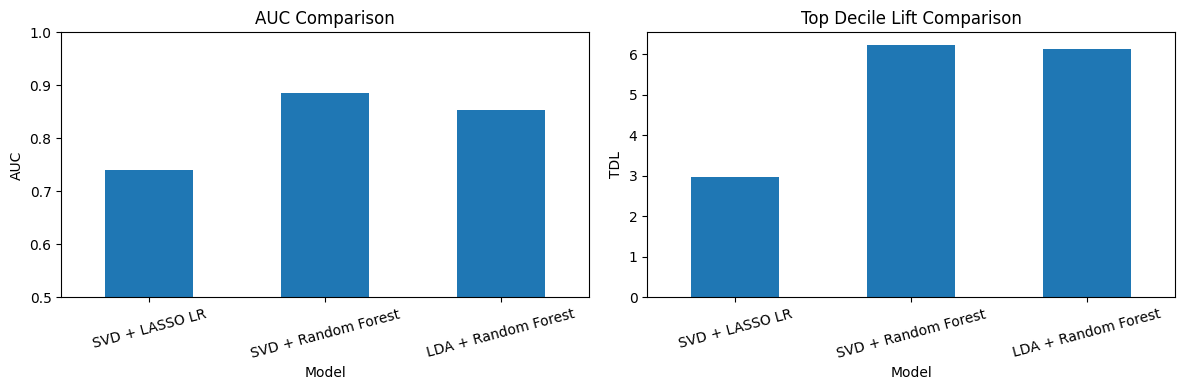

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

results.plot.bar(x='Model', y='AUC', ax=axes[0], legend=False, rot=15)
axes[0].set_title('AUC Comparison')
axes[0].set_ylabel('AUC')
axes[0].set_ylim(0.5, 1.0)

results.plot.bar(x='Model', y='Top Decile Lift', ax=axes[1], legend=False, rot=15)
axes[1].set_title('Top Decile Lift Comparison')
axes[1].set_ylabel('TDL')

plt.tight_layout()
plt.show()

## Discussion

- **SVD + RF** typically performs better than **SVD + LASSO LR**, as Random Forest can capture non-linear relationships between the SVD dimensions and the target.
- **LDA + RF** provides a different decomposition that focuses on topical structure rather than variance maximization. Performance may differ depending on how well the topic structure aligns with the prediction task.
- **Differences with Schetgen et al. (2021)** can be partly attributed to the fact that Logistic Regression is considerably more sensitive to the choice of $k$ than Random Forest:
  - **Logistic Regression** maps the SVD dimensions directly to a log-odds via a linear function. If $k$ is too small, the model loses proper predictive power that was discarded by the truncation. If $k$ is too large, the extra dimensions carry mostly noise, and even L1 regularisation may not fully compensate. The result is that LR performance can vary substantially across values of $k$.
  - **Random Forest**, by contrast, is much more robust to the inclusion of extra, low-signal SVD dimensions, and its performance is therefore less sensitive to the exact choice of $k$.